In [1]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib


C:\Users\bekba\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning:

TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.

C:\Users\bekba\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning:

Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.

C:\Users\bekba\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning:

TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.



In [3]:
# ════════════════════════════════════════════════════════════
# Load all 6 networks
# ════════════════════════════════════════════════════════════
networks = {
    'S0 Baseline':    r"C:\Users\bekba\Desktop\S0_base_s_5___2050.nc",
    'S1 Insulation':  r"C:\Users\bekba\Desktop\S1_5_2050.nc",
    'S2 Heat Pumps':  r"C:\Users\bekba\Desktop\S2_heat_pumps_only_s_5___2050.nc",
    'S3 (29%)':       r"C:\Users\bekba\Desktop\S3_combined_moderate_s_5___2050.nc",
    'S3-Low (15%)':   r"C:\Users\bekba\Desktop\S3_combined_low_retrofit_s_5___2050.nc",
    'S3-High (45%)':  r"C:\Users\bekba\Desktop\S3_combined_high_retrofit_s_5___2050.nc",
}

scenarios = {name: pypsa.Network(path) for name, path in networks.items()}

colors_s = {
    'S0 Baseline':   '#F44336',
    'S1 Insulation': '#2196F3',
    'S2 Heat Pumps': '#4CAF50',
    'S3 (29%)':      '#FF9800',
    'S3-Low (15%)':  '#FFC107',
    'S3-High (45%)': '#E65100',
}


INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current:

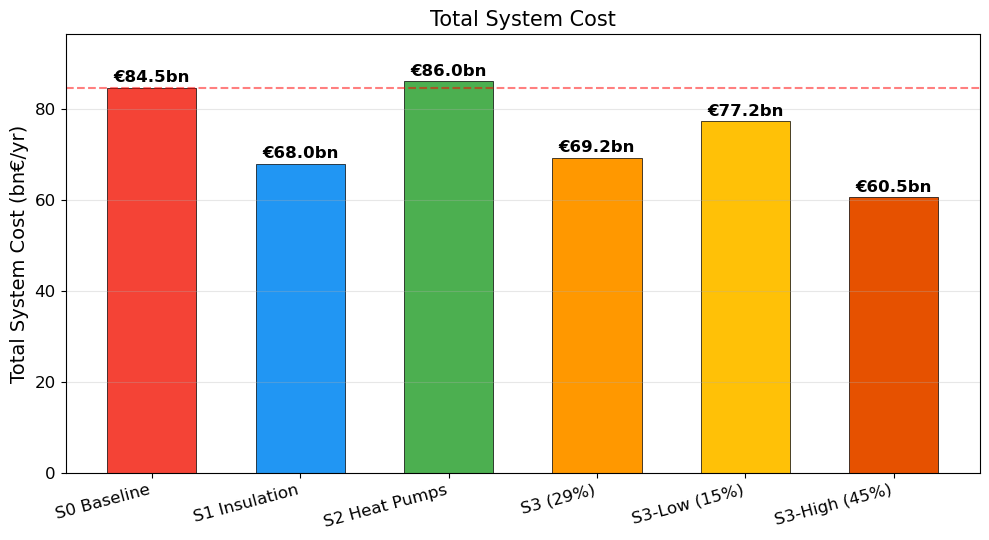

In [5]:
# ════════════════════════════════════════════════════════════
# GRAPH 1: System Cost — All 6 Scenarios
# ════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5.5))  # smaller figure

costs = {s: n.objective / 1e9 for s, n in scenarios.items()}

bars = ax.bar(
    costs.keys(),
    costs.values(),
    color=[colors_s[s] for s in costs.keys()],
    width=0.6,
    edgecolor='black',
    linewidth=0.5
)

# Axis labels and title
ax.set_ylabel('Total System Cost (bn€/yr)', fontsize=14)
ax.set_title('Total System Cost', fontsize=15)

# Bar labels
for bar, val in zip(bars, costs.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.6,
        f'€{val:.1f}bn',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Baseline line
ax.axhline(
    y=costs['S0 Baseline'],
    color='red',
    linestyle='--',
    linewidth=1.5,
    alpha=0.5,
    label='S0 Baseline'
)

# Limits and grid
ax.set_ylim(0, max(costs.values()) * 1.12)
ax.grid(True, alpha=0.3, axis='y')

# Bigger tick labels
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

plt.xticks(rotation=15, ha='right')

plt.tight_layout()



plt.show()



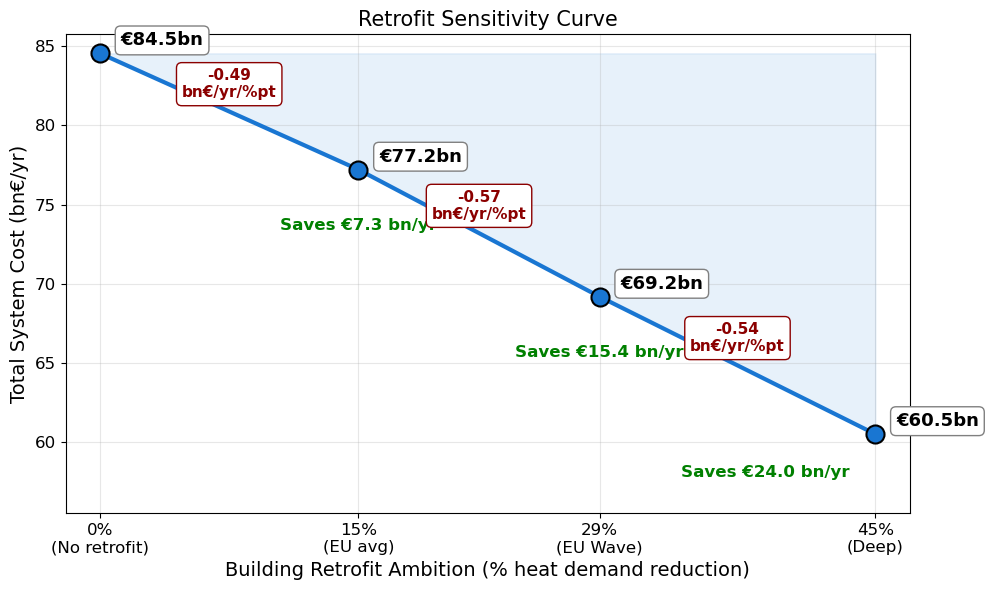

In [7]:
# ════════════════════════════════════════════════════════════
# GRAPH 2: RETROFIT SENSITIVITY CURVE — THE KEY THESIS GRAPH
# ════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

retrofit_curve = {
    0.00: costs['S0 Baseline'],
    0.15: costs['S3-Low (15%)'],
    0.29: costs['S3 (29%)'],
    0.45: costs['S3-High (45%)'],
}

x_pct = [k * 100 for k in retrofit_curve.keys()]
y_cost = list(retrofit_curve.values())

# Main curve
ax.plot(
    x_pct,
    y_cost,
    marker='o',
    markersize=13,
    linewidth=3,
    color='#1976D2',
    markerfacecolor='#1976D2',
    markeredgecolor='black',
    markeredgewidth=1.5
)

# Shaded area
ax.fill_between(
    x_pct,
    y_cost,
    max(y_cost),
    alpha=0.1,
    color='#1976D2'
)

# Point labels
for x, y in zip(x_pct, y_cost):
    ax.annotate(
        f'€{y:.1f}bn',
        xy=(x, y),
        xytext=(x + 1.2, y + 0.5),
        fontsize=13,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='gray'
        )
    )

# ════════════════════════════════════════════════════════════
# SAVINGS ANNOTATIONS
# ════════════════════════════════════════════════════════════

savings_15 = costs['S0 Baseline'] - costs['S3-Low (15%)']
savings_29 = costs['S0 Baseline'] - costs['S3 (29%)']
savings_45 = costs['S0 Baseline'] - costs['S3-High (45%)']

ax.text(
    15,
    costs['S3-Low (15%)'] - 3.8,
    f'Saves €{savings_15:.1f} bn/yr',
    ha='center',
    fontsize=12,
    color='green',
    fontweight='bold'
)

ax.text(
    29,
    costs['S3 (29%)'] - 3.8,
    f'Saves €{savings_29:.1f} bn/yr',
    ha='center',
    fontsize=12,
    color='green',
    fontweight='bold'
)

ax.text(
    43.5,
    costs['S3-High (45%)'] - 2.7,
    f'Saves €{savings_45:.1f} bn/yr',
    ha='right',
    fontsize=12,
    color='green',
    fontweight='bold'
)

# ════════════════════════════════════════════════════════════
# SLOPE LABELS — CENTERED BUT SLIGHTLY ABOVE THE LINE
# ════════════════════════════════════════════════════════════

for i in range(len(x_pct) - 1):

    x1, x2 = x_pct[i], x_pct[i + 1]
    y1, y2 = y_cost[i], y_cost[i + 1]

    slope = (y2 - y1) / (x2 - x1)

    # Geometric center of each line segment
    xm = (x1 + x2) / 2
    ym = (y1 + y2) / 2

    ax.annotate(
        f'{slope:.2f}\nbn€/yr/%pt',
        xy=(xm, ym),
        xytext=(0, 8),             # above the center
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=11,
        color='darkred',
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.35',
            facecolor='white',
            edgecolor='darkred'
        )
    )

# ════════════════════════════════════════════════════════════
# AXES AND STYLING
# ════════════════════════════════════════════════════════════

ax.set_xlabel(
    'Building Retrofit Ambition (% heat demand reduction)',
    fontsize=14
)

ax.set_ylabel(
    'Total System Cost (bn€/yr)',
    fontsize=14
)

ax.set_title(
    'Retrofit Sensitivity Curve',
    fontsize=15
)

ax.grid(True, alpha=0.3)

ax.set_xticks([0, 15, 29, 45])

ax.set_xticklabels(
    [
        '0%\n(No retrofit)',
        '15%\n(EU avg)',
        '29%\n(EU Wave)',
        '45%\n(Deep)'
    ],
    fontsize=12
)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

# Space so labels do not get clipped
ax.set_xlim(-2, 47)
ax.set_ylim(min(y_cost) - 5, max(y_cost) + 1.2)

plt.tight_layout()


plt.show()



In [9]:
# ════════════════════════════════════════════════════════════
# GRAPH 5: Final KPI Table — All 6 Scenarios
# ════════════════════════════════════════════════════════════
def get_metrics(n):
    w = n.snapshot_weightings.generators
    
    elec_loads = n.loads[n.loads.carrier=='electricity'].index
    base_elec = n.loads_t.p_set[elec_loads].abs().sum(axis=1)
    hp_links = n.links[n.links.carrier.str.contains('heat pump')].index
    hp_elec = n.links_t.p0[hp_links].abs().sum(axis=1) if len(hp_links) > 0 else 0
    res_links = n.links[n.links.carrier.str.contains('resistive')].index
    res_elec = n.links_t.p0[res_links].abs().sum(axis=1) if len(res_links) > 0 else 0
    total_elec = (base_elec + hp_elec + res_elec) / 1e3
    
    heat_loads = n.loads[n.loads.carrier.str.contains('heat', case=False)].index
    total_heat = n.loads_t.p_set[heat_loads].abs().sum(axis=1) / 1e3
    
    return {
        'Total cost (bn€/yr)':    round(n.objective/1e9, 1),
        'Peak elec (GW)':         round(total_elec.max(), 0),
        'Peak heat (GW)':         round(total_heat.max(), 0),
        'Annual elec (TWh)':      round((total_elec*w).sum()/1e3, 0),
        'Annual heat (TWh)':      round((total_heat*w).sum()/1e3, 0),
        'Onshore wind (GW)':      round(n.generators.p_nom_opt[n.generators.carrier=='onwind'].sum()/1e3, 1),
        'Total solar (GW)':       round(n.generators.p_nom_opt[n.generators.carrier.str.contains('solar')].sum()/1e3, 1),
        'Heat pumps (GW)':        round(n.links.p_nom_opt[n.links.carrier.str.contains('heat pump')].sum()/1e3, 1),
        'Gas boilers (GW)':       round(n.links.p_nom_opt[n.links.carrier.str.contains('boiler')].sum()/1e3, 1),
        'Gas CHP (GW)':           round(n.links.p_nom_opt[n.links.carrier.str.contains('CHP')].sum()/1e3, 1),
        'Battery (GWh)':          round(n.stores.e_nom_opt[n.stores.carrier=='battery'].sum()/1e3, 0),
        'Thermal storage (GWh)':  round(n.stores.e_nom_opt[n.stores.carrier=='urban central water pits'].sum()/1e3, 0),
    }

print("\nGenerating KPI table...")
kpi_df = pd.DataFrame({name: get_metrics(n) for name, n in scenarios.items()})

# Add saving row
s0_cost = scenarios['S0 Baseline'].objective/1e9
saving_row = {name: round(s0_cost - n.objective/1e9, 1) for name, n in scenarios.items()}
kpi_df.loc['Saving vs S0 (bn€/yr)'] = saving_row

print(kpi_df.to_string())



Generating KPI table...
                       S0 Baseline  S1 Insulation  S2 Heat Pumps  S3 (29%)  S3-Low (15%)  S3-High (45%)
Total cost (bn€/yr)           84.5           68.0           86.0      69.2          77.2           60.5
Peak elec (GW)               224.0          173.0          243.0     187.0         213.0          159.0
Peak heat (GW)               271.0          196.0          271.0     196.0         232.0          154.0
Annual elec (TWh)           1050.0          859.0         1065.0     885.0         983.0          778.0
Annual heat (TWh)            739.0          555.0          739.0     555.0         644.0          453.0
Onshore wind (GW)            138.3          104.6          140.8     108.2         123.3           93.2
Total solar (GW)             274.6          244.2          266.2     234.9         251.8          219.5
Heat pumps (GW)              116.4           74.6          139.6      92.5         114.7           66.0
Gas boilers (GW)              40.9     

In [11]:
print("\n" + "=" * 60)
print("NEW CAPACITY BUILT — Comparison across all scenarios")
print("=" * 60)

networks = {
    'S0':    r"C:\Users\bekba\Desktop\S0_base_s_5___2050.nc",
    'S1':  r"C:\Users\bekba\Desktop\S1_5_2050.nc",
    'S2':       r"C:\Users\bekba\Desktop\S2_heat_pumps_only_s_5___2050.nc",
    'S3':       r"C:\Users\bekba\Desktop\S3_combined_moderate_s_5___2050.nc",
    'S3-Low':   r"C:\Users\bekba\Desktop\S3_combined_low_retrofit_s_5___2050.nc",
    'S3-High':  r"C:\Users\bekba\Desktop\S3_combined_high_retrofit_s_5___2050.nc",
}

rows = []
for name, path in networks.items():
    net = pypsa.Network(path)

    def new_gen(carrier):
        mask = net.generators.carrier == carrier
        return (net.generators.p_nom_opt[mask] -
                net.generators.p_nom[mask]).sum()/1e3

    def new_link(kw):
        mask = net.links.carrier.str.contains(kw, case=False)
        return (net.links.p_nom_opt[mask] -
                net.links.p_nom[mask]).sum()/1e3

    def new_store(carrier):
        mask = net.stores.carrier == carrier
        return (net.stores.e_nom_opt[mask] -
                net.stores.e_nom[mask]).sum()/1e3

    rows.append({
        'Scenario':              name,
        # POWER SECTOR
        'Wind NEW (GW)':         round(new_gen('onwind'), 1),
        'Solar HSAT NEW (GW)':   round(new_gen('solar-hsat'), 1),
        'Trans NEW (GW)':        round((net.lines.s_nom_opt -
                                        net.lines.s_nom).sum()/1e3, 1),
        # HEAT SECTOR
        'HP NEW (GW)':           round(new_link('heat pump'), 1),
        'Boiler NEW (GW)':       round(new_link('boiler'), 1),
        'CHP NEW (GW)':          round(new_link('CHP'), 1),
        # STORAGE
        'Battery NEW (GWh)':     round(new_store('battery'), 1),
        'TES NEW (GWh)':         round(new_store(
                                   'urban central water pits'), 1),
    })

df = pd.DataFrame(rows).set_index('Scenario')

# ── Table 1: Power Sector ─────────────────────────────────
power_cols = ['Wind NEW (GW)', 'Solar HSAT NEW (GW)', 'Trans NEW (GW)']
print("TABLE 1 — POWER SECTOR INVESTMENTS (G_n,s, F_l)")
print("=" * 55)
print(df[power_cols].to_string())

# ── Table 2: Heat Sector + Storage ───────────────────────
heat_cols = ['HP NEW (GW)', 'Boiler NEW (GW)',
             'CHP NEW (GW)', 'Battery NEW (GWh)', 'TES NEW (GWh)']
print("\nTABLE 2 — HEAT SECTOR + STORAGE INVESTMENTS (G_n,s, E_n,r)")
print("=" * 65)
print(df[heat_cols].to_string())

# ── Note on constants ─────────────────────────────────────
print("\nCONSTANT ACROSS ALL SCENARIOS (not decision variables):")
print("  Solar utility NEW    = 0.0 GW  (existing capacity sufficient)")
print("  Solar rooftop NEW    = 160.6 GW (exogenously fixed in model)")
print("  Solar thermal NEW    = 0.0 GW  (not cost-competitive)")


NEW CAPACITY BUILT — Comparison across all scenarios


INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current:

TABLE 1 — POWER SECTOR INVESTMENTS (G_n,s, F_l)
          Wind NEW (GW)  Solar HSAT NEW (GW)  Trans NEW (GW)
Scenario                                                    
S0                 64.9                 65.2            10.9
S1                 31.2                 34.9             2.2
S2                 67.5                 56.8            10.8
S3                 34.8                 25.5             1.3
S3-Low             49.9                 42.4             5.6
S3-High            19.9                 10.1             0.0

TABLE 2 — HEAT SECTOR + STORAGE INVESTMENTS (G_n,s, E_n,r)
          HP NEW (GW)  Boiler NEW (GW)  CHP NEW (GW)  Battery NEW (GWh)  TES NEW (GWh)
Scenario                                                                              
S0              116.4             40.9         160.1              337.4         7746.0
S1               74.6             31.8         132.4              286.6         4550.8
S2              139.6              0.0         182.6    

In [13]:
scenarios = {name: pypsa.Network(path) for name, path in networks.items()}

def new_gen(n, carrier):
    mask = n.generators.carrier == carrier
    return (n.generators.p_nom_opt[mask] -
            n.generators.p_nom[mask]).sum() / 1e3

def new_link(n, kw):
    mask = n.links.carrier.str.contains(kw, case=False)
    return (n.links.p_nom_opt[mask] -
            n.links.p_nom[mask]).sum() / 1e3

def new_store(n, carrier):
    mask = n.stores.carrier == carrier
    return (n.stores.e_nom_opt[mask] -
            n.stores.e_nom[mask]).sum() / 1e3

def new_trans(n):
    return (n.lines.s_nom_opt - n.lines.s_nom).sum() / 1e3

labels = list(scenarios.keys())
x = np.arange(len(labels))
width = 0.25

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current:

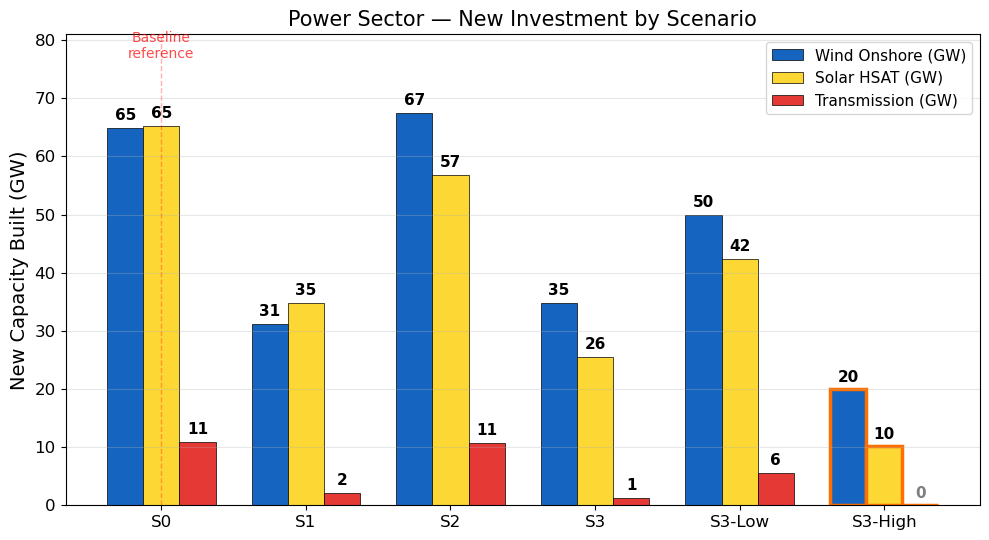

In [15]:
# ════════════════════════════════════════════════════════
# CHART 1 — POWER SECTOR
# ════════════════════════════════════════════════════════

wind_new   = [new_gen(n, 'onwind')     for n in scenarios.values()]
hsat_new   = [new_gen(n, 'solar-hsat') for n in scenarios.values()]
trans_new  = [new_trans(n)             for n in scenarios.values()]

fig, ax = plt.subplots(figsize=(10, 5.5))  # smaller figure

bars1 = ax.bar(
    x - width,
    wind_new,
    width,
    label='Wind Onshore (GW)',
    color='#1565C0',
    edgecolor='black',
    linewidth=0.5
)

bars2 = ax.bar(
    x,
    hsat_new,
    width,
    label='Solar HSAT (GW)',
    color='#FDD835',
    edgecolor='black',
    linewidth=0.5
)

bars3 = ax.bar(
    x + width,
    trans_new,
    width,
    label='Transmission (GW)',
    color='#E53935',
    edgecolor='black',
    linewidth=0.5
)

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()

        if h > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.8,
                f'{h:.0f}',
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold'
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.8,
                '0',
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold',
                color='gray'
            )

# Highlight S3-High with border
for bars in [bars1, bars2, bars3]:
    bars[-1].set_edgecolor('#FF6F00')
    bars[-1].set_linewidth(2.5)

# Labels and title
ax.set_ylabel('New Capacity Built (GW)', fontsize=14)
ax.set_title(
    'Power Sector — New Investment by Scenario',
    fontsize=15
)

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

# Y-axis
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

# Legend
ax.legend(fontsize=11, loc='upper right')

# Limits and grid
ax.set_ylim(0, max(wind_new) * 1.2)
ax.grid(True, alpha=0.3, axis='y')

# Annotate S0 as reference
ax.axvline(
    x=0,
    color='red',
    linestyle='--',
    alpha=0.3,
    linewidth=1
)

ax.text(
    0,
    ax.get_ylim()[1] * 0.95,
    'Baseline\nreference',
    ha='center',
    fontsize=10,
    color='red',
    alpha=0.7
)

plt.tight_layout()



plt.show()



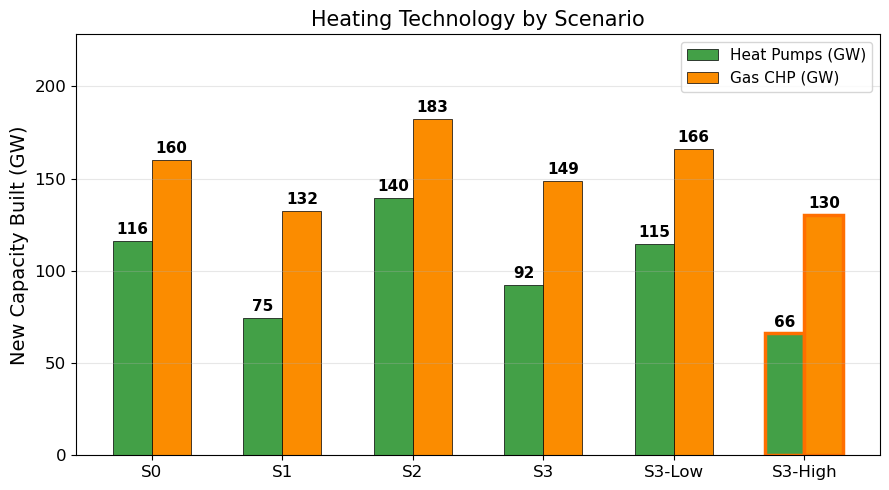

In [17]:
# ════════════════════════════════════════════════════════
# CHART 2A — HEAT SECTOR
# ════════════════════════════════════════════════════════

hp_new  = [new_link(n, 'heat pump') for n in scenarios.values()]
chp_new = [new_link(n, 'CHP')       for n in scenarios.values()]

fig, ax1 = plt.subplots(figsize=(9, 5))

width2 = 0.3

b1 = ax1.bar(
    x - width2/2,
    hp_new,
    width2,
    label='Heat Pumps (GW)',
    color='#43A047',
    edgecolor='black',
    linewidth=0.5
)

b2 = ax1.bar(
    x + width2/2,
    chp_new,
    width2,
    label='Gas CHP (GW)',
    color='#FB8C00',
    edgecolor='black',
    linewidth=0.5
)

# Value labels
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h + 2,
            f'{h:.0f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Highlight S3-High
    bars[-1].set_edgecolor('#FF6F00')
    bars[-1].set_linewidth(2.5)

ax1.set_ylabel('New Capacity Built (GW)', fontsize=14)
ax1.set_title('Heating Technology by Scenario', fontsize=15)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)

ax1.tick_params(axis='y', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)

ax1.legend(fontsize=11, loc='upper right')

ax1.set_ylim(0, max(chp_new) * 1.25)
ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()


plt.show()



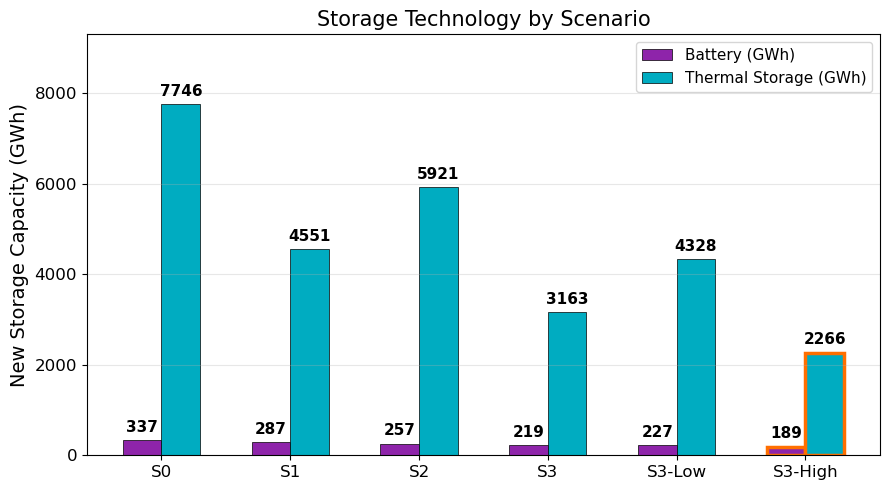

In [19]:
# ════════════════════════════════════════════════════════
# CHART 2B — STORAGE SECTOR
# ════════════════════════════════════════════════════════

battery_new = [new_store(n, 'battery') for n in scenarios.values()]
tes_new     = [new_store(n, 'urban central water pits') for n in scenarios.values()]

fig, ax2 = plt.subplots(figsize=(9, 5))

width2 = 0.3

b3 = ax2.bar(
    x - width2/2,
    battery_new,
    width2,
    label='Battery (GWh)',
    color='#8E24AA',
    edgecolor='black',
    linewidth=0.5
)

b4 = ax2.bar(
    x + width2/2,
    tes_new,
    width2,
    label='Thermal Storage (GWh)',
    color='#00ACC1',
    edgecolor='black',
    linewidth=0.5
)

# Value labels
for bars in [b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width()/2,
            h + max(tes_new) * 0.015,
            f'{h:.0f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Highlight S3-High
    bars[-1].set_edgecolor('#FF6F00')
    bars[-1].set_linewidth(2.5)

ax2.set_ylabel('New Storage Capacity (GWh)', fontsize=14)
ax2.set_title('Storage Technology by Scenario', fontsize=15)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=12)

ax2.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='x', labelsize=12)

ax2.legend(fontsize=11, loc='upper right')

ax2.set_ylim(0, max(tes_new) * 1.2)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()



plt.show()



In [21]:
print("="*80)
print("DEMAND PROFILE ANALYSIS — ALL 6 SCENARIOS")
print("="*80)

results = {}

for name, n in scenarios.items():   # ← n is already loaded, no pypsa.Network() call

    # Heat demand (exogenous)
    heat_loads = n.loads[
        n.loads.carrier.str.contains('heat', case=False)
    ].index
    heat_TS = n.loads_t.p_set[heat_loads].sum(axis=1) / 1e3

    # Electricity demand from heating
    hp_links = n.links[
        n.links.carrier.str.contains('heat pump', case=False)
    ].index
    res_links = n.links[
        n.links.carrier.str.contains('resistive', case=False)
    ].index

    hp_elec_TS = (
        n.links_t.p0[hp_links].abs().sum(axis=1) / 1e3
        if len(hp_links) > 0
        else pd.Series(0, index=n.snapshots)
    )
    res_elec_TS = (
        n.links_t.p0[res_links].abs().sum(axis=1) / 1e3
        if len(res_links) > 0
        else pd.Series(0, index=n.snapshots)
    )
    elec_heating_TS = hp_elec_TS + res_elec_TS

    # Metrics
    heat_peak = heat_TS.max()
    heat_avg  = heat_TS.mean()
    elec_peak = elec_heating_TS.max()
    elec_avg  = elec_heating_TS.mean()

    heat_PA   = heat_peak / heat_avg if heat_avg > 0 else 0
    elec_PA   = elec_peak / elec_avg if elec_avg > 0 else 0
    smoothing = (1 - elec_PA / heat_PA) * 100 if heat_PA > 0 else 0

    print(f"\n{name}")
    print(f"  Heat demand:        Peak={heat_peak:>6.0f} GW, "
          f"Avg={heat_avg:>5.0f} GW, Peak/Avg={heat_PA:.2f}")
    print(f"  Elec from heating:  Peak={elec_peak:>6.0f} GW, "
          f"Avg={elec_avg:>5.0f} GW, Peak/Avg={elec_PA:.2f}")
    print(f"  Smoothing effect:   {smoothing:+.1f}% "
          f"({'smoother' if smoothing > 0 else 'sharper'} elec profile)")

    results[name] = {
        'heat':      heat_TS,
        'elec':      elec_heating_TS,
        'heat_PA':   heat_PA,
        'elec_PA':   elec_PA,
        'smoothing': smoothing,
    }

print("\n✅ Demand profile analysis complete.")

DEMAND PROFILE ANALYSIS — ALL 6 SCENARIOS

S0
  Heat demand:        Peak=   271 GW, Avg=   84 GW, Peak/Avg=3.21
  Elec from heating:  Peak=   170 GW, Avg=   67 GW, Peak/Avg=2.55
  Smoothing effect:   +20.7% (smoother elec profile)

S1
  Heat demand:        Peak=   196 GW, Avg=   63 GW, Peak/Avg=3.09
  Elec from heating:  Peak=   115 GW, Avg=   45 GW, Peak/Avg=2.56
  Smoothing effect:   +17.0% (smoother elec profile)

S2
  Heat demand:        Peak=   271 GW, Avg=   84 GW, Peak/Avg=3.21
  Elec from heating:  Peak=   186 GW, Avg=   68 GW, Peak/Avg=2.72
  Smoothing effect:   +15.2% (smoother elec profile)

S3
  Heat demand:        Peak=   196 GW, Avg=   63 GW, Peak/Avg=3.09
  Elec from heating:  Peak=   133 GW, Avg=   48 GW, Peak/Avg=2.78
  Smoothing effect:   +9.8% (smoother elec profile)

S3-Low
  Heat demand:        Peak=   232 GW, Avg=   73 GW, Peak/Avg=3.16
  Elec from heating:  Peak=   159 GW, Avg=   59 GW, Peak/Avg=2.70
  Smoothing effect:   +14.6% (smoother elec profile)

S3-High
 


Peak heat demand day in S0: 2013-01-25


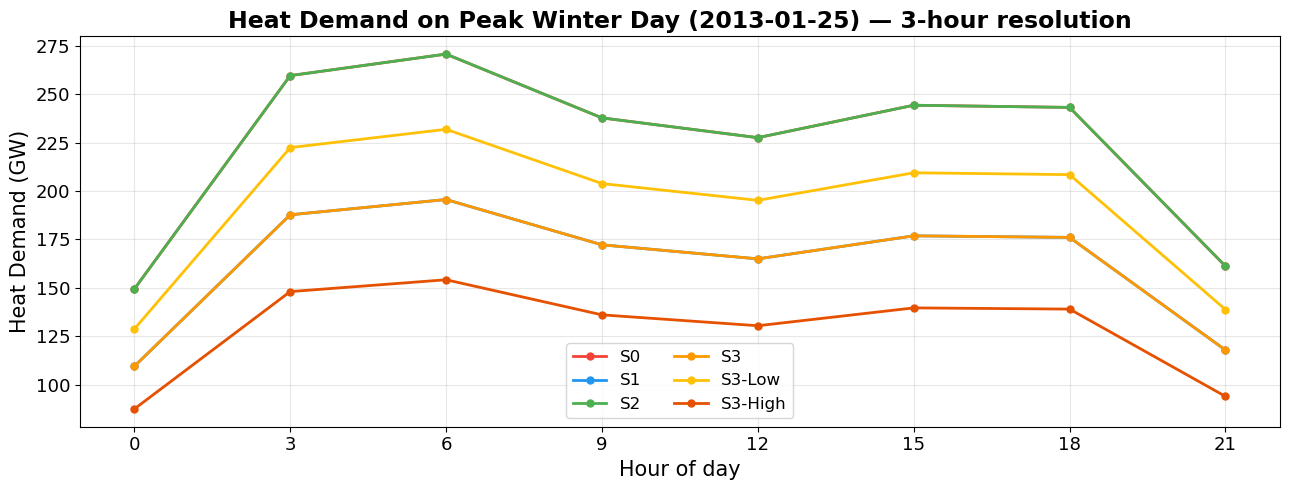

In [23]:
# ════════════════════════════════════════════════════════════
# CHART 2A — HEAT DEMAND ON PEAK WINTER DAY
# ════════════════════════════════════════════════════════════
colors_s = {
    'S0':       '#F44336',
    'S1':       '#2196F3',
    'S2':       '#4CAF50',
    'S3':       '#FF9800',
    'S3-Low':   '#FFC107',
    'S3-High':  '#E65100',
}
colors = colors_s
# Find the peak demand day across S0 (reference)
s0_heat = results['S0']['heat']
peak_day = s0_heat.idxmax().date()
print(f"\nPeak heat demand day in S0: {peak_day}")

# ---------- Figure 1: Heat demand ----------
fig, ax = plt.subplots(figsize=(13, 5))

for name, r in results.items():
    day_data = r['heat'].loc[str(peak_day)]
    ax.plot(
        day_data.index.hour,
        day_data.values,
        label=name,
        color=colors[name],
        linewidth=2,
        marker='o',
        markersize=5
    )

ax.set_title(
    f'Heat Demand on Peak Winter Day ({peak_day}) — 3-hour resolution',
    fontsize=17,
    fontweight='bold'
)

ax.set_ylabel('Heat Demand (GW)', fontsize=15)
ax.set_xlabel('Hour of day', fontsize=15)

ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 24, 3))

plt.tight_layout()

plt.show()



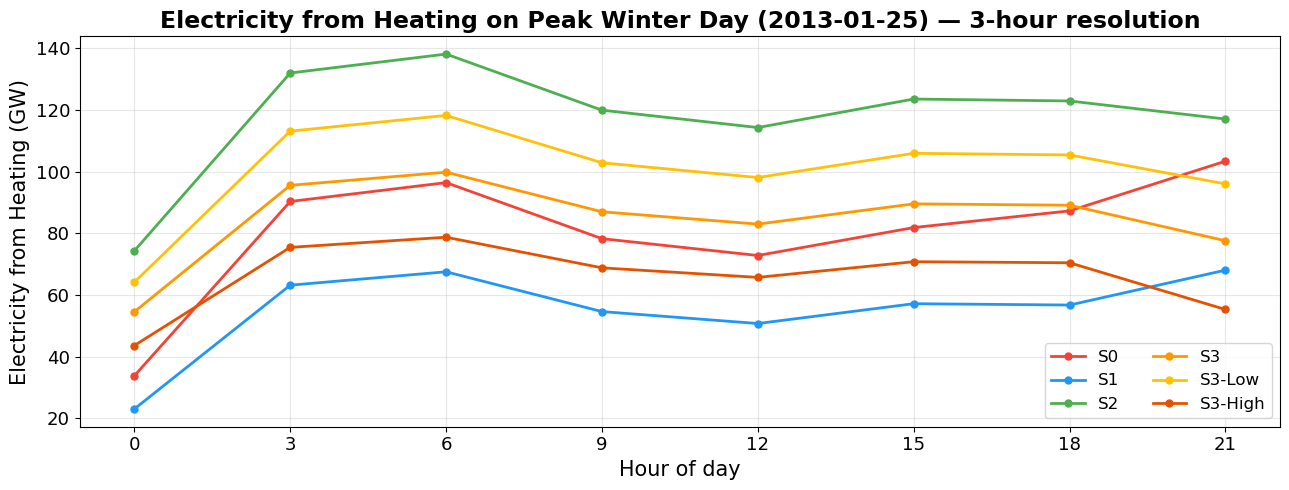

In [25]:
# ════════════════════════════════════════════════════════════
# CHART 2B — ELECTRICITY FROM HEATING ON PEAK WINTER DAY
# ════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 5))

for name, r in results.items():
    day_data = r['elec'].loc[str(peak_day)]
    ax.plot(
        day_data.index.hour,
        day_data.values,
        label=name,
        color=colors[name],
        linewidth=2,
        marker='o',
        markersize=5
    )

ax.set_title(
    f'Electricity from Heating on Peak Winter Day ({peak_day}) — 3-hour resolution',
    fontsize=17,
    fontweight='bold'
)

ax.set_ylabel('Electricity from Heating (GW)', fontsize=15)
ax.set_xlabel('Hour of day', fontsize=15)

ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 24, 3))

plt.tight_layout()

plt.show()



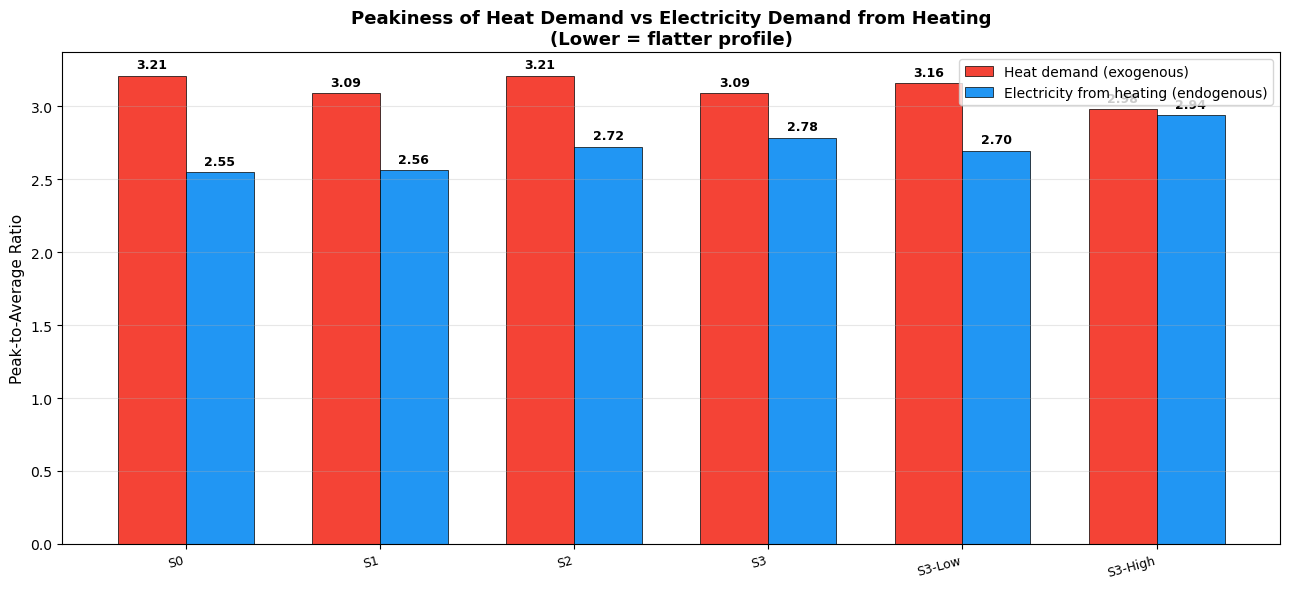

In [27]:
# ════════════════════════════════════════════════════════════
# CHART 5 — PEAK-TO-AVERAGE RATIO COMPARISON
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(scenarios))
width = 0.35

heat_PAs = [results[s]['heat_PA'] for s in scenarios.keys()]
elec_PAs = [results[s]['elec_PA'] for s in scenarios.keys()]

bars1 = ax.bar(x - width/2, heat_PAs, width,
               label='Heat demand (exogenous)',
               color='#F44336', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, elec_PAs, width,
               label='Electricity from heating (endogenous)',
               color='#2196F3', edgecolor='black', linewidth=0.5)

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                f'{h:.2f}', ha='center', fontweight='bold', fontsize=9)

ax.set_ylabel('Peak-to-Average Ratio', fontsize=11)
ax.set_title('Peakiness of Heat Demand vs Electricity Demand from Heating\n'
             '(Lower = flatter profile)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scenarios.keys(), fontsize=9, rotation=15, ha='right')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

plt.show()


In [29]:
# ════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("SUMMARY TABLE — DEMAND PROFILE METRICS")
print("="*80)

summary = pd.DataFrame({
    'Heat Peak (GW)':     [round(results[s]['heat'].max(), 0)
                           for s in scenarios.keys()],
    'Heat Avg (GW)':      [round(results[s]['heat'].mean(), 0)
                           for s in scenarios.keys()],
    'Heat Peak/Avg':      [round(results[s]['heat_PA'], 2)
                           for s in scenarios.keys()],
    'Elec Peak (GW)':     [round(results[s]['elec'].max(), 0)
                           for s in scenarios.keys()],
    'Elec Avg (GW)':      [round(results[s]['elec'].mean(), 0)
                           for s in scenarios.keys()],
    'Elec Peak/Avg':      [round(results[s]['elec_PA'], 2)
                           for s in scenarios.keys()],
    'Smoothing (%)':      [round(results[s]['smoothing'], 1)
                           for s in scenarios.keys()],
}, index=scenarios.keys())

print(summary.to_string())




SUMMARY TABLE — DEMAND PROFILE METRICS
         Heat Peak (GW)  Heat Avg (GW)  Heat Peak/Avg  Elec Peak (GW)  Elec Avg (GW)  Elec Peak/Avg  Smoothing (%)
S0                271.0           84.0           3.21           170.0           67.0           2.55           20.7
S1                196.0           63.0           3.09           115.0           45.0           2.56           17.0
S2                271.0           84.0           3.21           186.0           68.0           2.72           15.2
S3                196.0           63.0           3.09           133.0           48.0           2.78            9.8
S3-Low            232.0           73.0           3.16           159.0           59.0           2.70           14.6
S3-High           154.0           52.0           2.98           105.0           36.0           2.94            1.4


In [31]:
# ════════════════════════════════════════════════════════════
# CO₂ AVOIDED ACROSS ALL SIX SCENARIOS
# ════════════════════════════════════════════════════════════

# Parameters (consistent with Section 3.7)
baseline_heat       = 739      # TWh/yr
gas_share_of_heat   = 0.50     # AGEB 2024
co2_factor          = 0.275    # tCO2/MWh_heat (Umweltbundesamt 2024)

# Demand reduction by scenario
demand_reduction = {
    'S0 Baseline':       0.00,
    'S1 Insulation':     0.29,
    'S2 Heat Pumps':     0.00,
    'S3 (29%)':          0.29,
    'S3-Low (15%)':      0.15,
    'S3-High (45%)':     0.45,
}

# Calculate CO₂ avoided for each scenario
# Note: S2 has no retrofit but bans gas boilers, so heat-side CO2 is 
# entirely eliminated for the gas-supplied portion (different mechanism)

co2_avoided = {}
for scenario, alpha in demand_reduction.items():
    if scenario == 'S2 Heat Pumps':
        # S2 eliminates gas boilers entirely; CO2 from gas heat → 0
        # All of the gas-supplied heat (50% of baseline) is electrified
        gas_supplied_heat = baseline_heat * gas_share_of_heat
        co2_avoided[scenario] = gas_supplied_heat * co2_factor
    elif scenario == 'S0 Baseline':
        co2_avoided[scenario] = 0
    else:
        # Other scenarios: avoid CO2 proportional to retrofit
        # (gas-supplied share that no longer needs heating)
        gas_supplied_heat = baseline_heat * gas_share_of_heat
        co2_avoided[scenario] = gas_supplied_heat * alpha * co2_factor

# Print summary
print("=" * 60)
print("CO₂ EMISSIONS AVOIDED BY SCENARIO")
print("=" * 60)
for scenario, value in co2_avoided.items():
    print(f"  {scenario:25s}  {value:>6.1f} MtCO₂/yr")


CO₂ EMISSIONS AVOIDED BY SCENARIO
  S0 Baseline                   0.0 MtCO₂/yr
  S1 Insulation                29.5 MtCO₂/yr
  S2 Heat Pumps               101.6 MtCO₂/yr
  S3 (29%)                     29.5 MtCO₂/yr
  S3-Low (15%)                 15.2 MtCO₂/yr
  S3-High (45%)                45.7 MtCO₂/yr


C:\Users\bekba\AppData\Local\Temp\ipykernel_5184\612622707.py:42: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



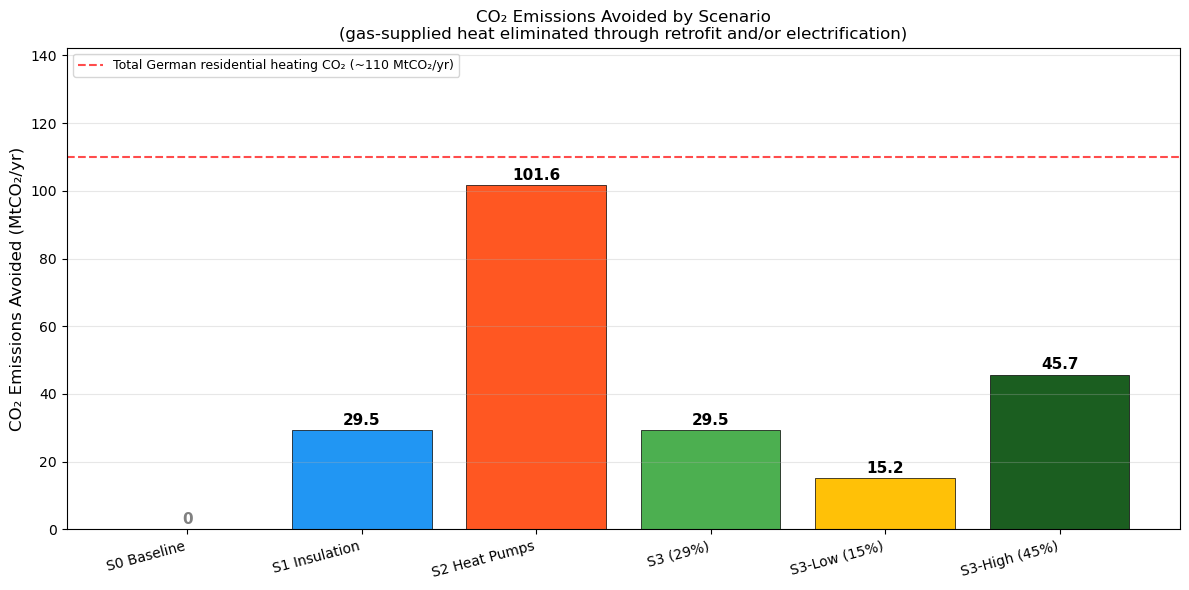

In [33]:

# ════════════════════════════════════════════════════════════
# BAR CHART
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

scenarios = list(co2_avoided.keys())
values = list(co2_avoided.values())

# Color coding by scenario type
colors = ['#9E9E9E',   # S0 — grey (baseline)
          '#2196F3',   # S1 — blue (insulation)
          '#FF5722',   # S2 — red-orange (electrification only)
          '#4CAF50',   # S3 — green (combined)
          '#FFC107',   # S3-Low — light yellow
          '#1B5E20']   # S3-High — dark green

bars = ax.bar(scenarios, values, color=colors,
              edgecolor='black', linewidth=0.5)

# Value labels on top of each bar
for bar, value in zip(bars, values):
    h = bar.get_height()
    if value > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
                f'{value:.1f}', ha='center',
                fontweight='bold', fontsize=11)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 1.5,
                '0', ha='center',
                fontweight='bold', fontsize=11, color='grey')
# Reference line: Germany's residential building emissions
# (approximately 110 MtCO2/yr based on Umweltbundesamt 2024)

ax.axhline(y=110, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Total German residential heating CO₂ (~110 MtCO₂/yr)')

ax.set_ylabel('CO₂ Emissions Avoided (MtCO₂/yr)', fontsize=12)
ax.set_title('CO₂ Emissions Avoided by Scenario\n'
             '(gas-supplied heat eliminated through retrofit and/or '
             'electrification)',
             fontsize=12)
ax.set_xticklabels(scenarios, fontsize=10, rotation=15, ha='right')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(values) * 1.4)

plt.tight_layout()

plt.show()



In [35]:


# ════════════════════════════════════════════════════════════
# PARAMETERS
# ════════════════════════════════════════════════════════════

# Building stock
total_floor_area    = 3700e6    # m² heated residential (BBSR 2022)

# Renovation parameters
renovation_rate     = {'15%': 0.01, '29%': 0.02, '45%': 0.03}
demand_reduction    = {'15%': 0.15, '29%': 0.29, '45%': 0.45}

# Retrofit costs (€/m²) — IWU 2024 mid estimate
retrofit_cost_per_m2 = {
    '15%': {'low': 150, 'mid': 225, 'high': 300},
    '29%': {'low': 350, 'mid': 500, 'high': 700},
    '45%': {'low': 600, 'mid': 900, 'high': 1200},
}

# Baseline heat demand (S0 PyPSA output)
baseline_heat       = 739       # TWh/yr

# Value stream parameters
co2_factor            = 0.275   # tCO2/MWh_heat (Umweltbundesamt 2024)
ets2_price            = 60      # €/tCO2 (EU 2027 cap)
security_premium      = 10      # €/MWh (own assumption; only additional beyond PyPSA)
boiler_efficiency     = 0.90    # IWU standard
co_benefit_per_m2     = 70      # €/m²/yr (BPIE 2018 mid)
gas_share_of_heat     = 0.50    # AGEB 2024

# System savings from PyPSA
system_savings_pypsa = {'15%': 7.3e9, '29%': 15.4e9, '45%': 24.0e9}

# ════════════════════════════════════════════════════════════
# CALCULATION
# ════════════════════════════════════════════════════════════
print("="*80)
print("CALIBRATED CBA — CORRECTED METHODOLOGY")
print("WITHOUT direct bill savings (removed to avoid double-counting")
print("with PyPSA wholesale gas costs)")
print("="*80)

results = {}

for scenario in ['15%', '29%', '45%']:
    rrate  = renovation_rate[scenario]
    alpha  = demand_reduction[scenario]
    costs  = retrofit_cost_per_m2[scenario]

    # ── Physical quantities ──────────────────────────────
    area_per_year   = total_floor_area * rrate
    heat_avoided    = baseline_heat * alpha
    heat_avoided_gas = heat_avoided * gas_share_of_heat
    gas_avoided      = heat_avoided_gas / boiler_efficiency
    co2_avoided      = heat_avoided_gas * co2_factor

    # ── Value streams (€ billion / yr) ───────────────────
    # 1. System savings (PyPSA — already includes wholesale gas costs)
    system_value = system_savings_pypsa[scenario] / 1e9

    # 2. Bill savings REMOVED (double-counted with PyPSA)
    bill_savings = 0  # Set to zero, not counted

    # 3. CO2 pricing — only gas-supplied portion (ETS2 not in PyPSA)
    co2_value = co2_avoided * 1e6 * ets2_price / 1e9

    # 4. Gas imports — security premium ONLY (wholesale in PyPSA)
    import_value = gas_avoided * 1e6 * security_premium / 1e9

    # 5. Co-benefits
    cobenefit_value = area_per_year * co_benefit_per_m2 / 1e9

    total_value = (system_value + co2_value + import_value + cobenefit_value)

    # ── Investment cost (€ billion / yr during campaign) ─
    annual_invest = {
        'low':  area_per_year * costs['low']  / 1e9,
        'mid':  area_per_year * costs['mid']  / 1e9,
        'high': area_per_year * costs['high'] / 1e9,
    }

    net_mid = total_value - annual_invest['mid']
    bcr_mid = total_value / annual_invest['mid']

    results[scenario] = {
        'area_per_year_Mm2': area_per_year / 1e6,
        'heat_avoided_TWh':  heat_avoided,
        'heat_avoided_gas':  heat_avoided_gas,
        'gas_avoided_TWh':   gas_avoided,
        'co2_avoided_Mt':    co2_avoided,
        'system_value':      system_value,
        'co2_value':         co2_value,
        'import_value':      import_value,
        'cobenefit_value':   cobenefit_value,
        'total_value':       total_value,
        'invest_low':        annual_invest['low'],
        'invest_mid':        annual_invest['mid'],
        'invest_high':       annual_invest['high'],
        'net_mid':           net_mid,
        'bcr_mid':           bcr_mid,
    }

    print(f"\n─── {scenario} retrofit ({rrate*100:.0f}%/yr renovation) ───")
    print(f"  Area renovated/yr:        {area_per_year/1e6:>8.0f} Mm²/yr")
    print(f"  Heat avoided (total):     {heat_avoided:>8.1f} TWh/yr")
    print(f"  Heat avoided (gas only):  {heat_avoided_gas:>8.1f} TWh/yr")
    print(f"  Gas burned avoided:       {gas_avoided:>8.1f} TWh/yr")
    print(f"  CO2 avoided:              {co2_avoided:>8.1f} MtCO2/yr")
    print()
    print(f"  Value streams (€bn/yr):")
    print(f"    System savings (PyPSA):   {system_value:>6.1f}  (includes gas cost)")
    print(f"    CO2 pricing (ETS2):       {co2_value:>6.1f}")
    print(f"    Security premium:         {import_value:>6.1f}")
    print(f"    Health/comfort:           {cobenefit_value:>6.1f}")
    print(f"    ─────────────────────────────")
    print(f"    TOTAL VALUE:              {total_value:>6.1f}")
    print()
    print(f"  Investment (€bn/yr):")
    print(f"    Low / Mid / High:    "
          f"{annual_invest['low']:.1f} / {annual_invest['mid']:.1f} / "
          f"{annual_invest['high']:.1f}")
    print()
    print(f"  Net annual benefit (mid):  €{net_mid:+.1f} bn/yr")
    print(f"  Benefit-cost ratio (mid):  {bcr_mid:.2f}x")


CALIBRATED CBA — CORRECTED METHODOLOGY
WITHOUT direct bill savings (removed to avoid double-counting
with PyPSA wholesale gas costs)

─── 15% retrofit (1%/yr renovation) ───
  Area renovated/yr:              37 Mm²/yr
  Heat avoided (total):        110.8 TWh/yr
  Heat avoided (gas only):      55.4 TWh/yr
  Gas burned avoided:           61.6 TWh/yr
  CO2 avoided:                  15.2 MtCO2/yr

  Value streams (€bn/yr):
    System savings (PyPSA):      7.3  (includes gas cost)
    CO2 pricing (ETS2):          0.9
    Security premium:            0.6
    Health/comfort:              2.6
    ─────────────────────────────
    TOTAL VALUE:                11.4

  Investment (€bn/yr):
    Low / Mid / High:    5.5 / 8.3 / 11.1

  Net annual benefit (mid):  €+3.1 bn/yr
  Benefit-cost ratio (mid):  1.37x

─── 29% retrofit (2%/yr renovation) ───
  Area renovated/yr:              74 Mm²/yr
  Heat avoided (total):        214.3 TWh/yr
  Heat avoided (gas only):     107.2 TWh/yr
  Gas burned avoided:

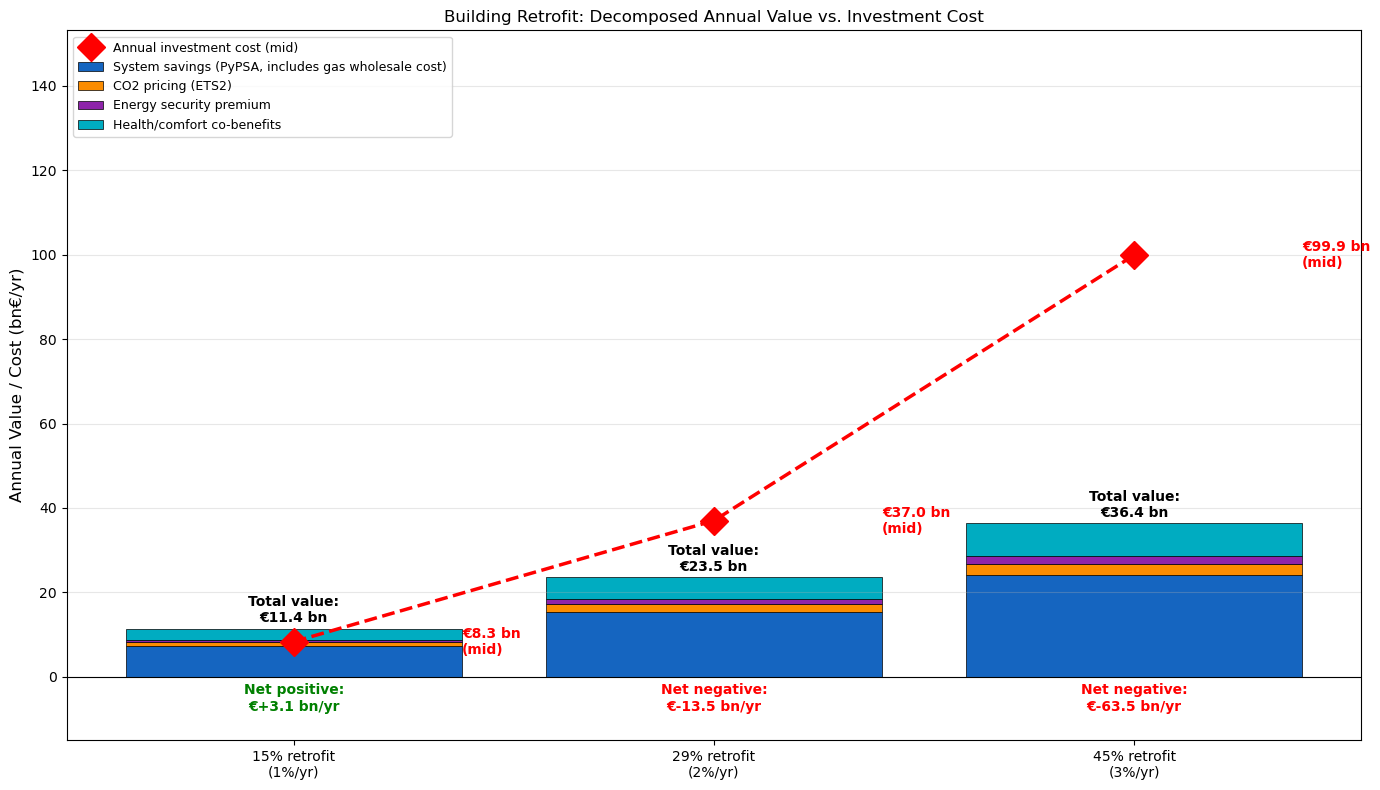


✅ Updated Figure 6.1 (no bill savings) saved to Desktop


In [37]:
# ════════════════════════════════════════════════════════════
# UPDATED CHART — Figure 6.1 WITHOUT BILL SAVINGS
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 8))
scenarios     = ['15% retrofit\n(1%/yr)',
                 '29% retrofit\n(2%/yr)',
                 '45% retrofit\n(3%/yr)']
x = np.arange(len(scenarios))

sys_vals  = [results[s]['system_value']    for s in ['15%', '29%', '45%']]
co2_vals  = [results[s]['co2_value']       for s in ['15%', '29%', '45%']]
imp_vals  = [results[s]['import_value']    for s in ['15%', '29%', '45%']]
hc_vals   = [results[s]['cobenefit_value'] for s in ['15%', '29%', '45%']]
inv_low   = [results[s]['invest_low']      for s in ['15%', '29%', '45%']]
inv_mid   = [results[s]['invest_mid']      for s in ['15%', '29%', '45%']]
inv_high  = [results[s]['invest_high']     for s in ['15%', '29%', '45%']]

# Stack the value bars
ax.bar(x, sys_vals,  label='System savings (PyPSA, includes gas wholesale cost)',
       color='#1565C0', edgecolor='black', linewidth=0.5)
bottom = np.array(sys_vals, dtype=float)

ax.bar(x, co2_vals, bottom=bottom,
       label='CO2 pricing (ETS2)',
       color='#FB8C00', edgecolor='black', linewidth=0.5)
bottom += np.array(co2_vals, dtype=float)

ax.bar(x, imp_vals, bottom=bottom,
       label='Energy security premium',
       color='#8E24AA', edgecolor='black', linewidth=0.5)
bottom += np.array(imp_vals, dtype=float)

ax.bar(x, hc_vals, bottom=bottom,
       label='Health/comfort co-benefits',
       color='#00ACC1', edgecolor='black', linewidth=0.5)

# Investment cost — show range with error bars
ax.plot(x, inv_mid, 'r--', marker='D', markersize=14, linewidth=2.5,
        label='Annual investment cost (mid)', zorder=5)



# Annotations
totals = [s+c+i+h for s,c,i,h in
          zip(sys_vals, co2_vals, imp_vals, hc_vals)]
nets   = [t - i for t, i in zip(totals, inv_mid)]

for i, (tot, inv, net) in enumerate(zip(totals, inv_mid, nets)):
    ax.text(i, tot + 1.5, f'Total value:\n€{tot:.1f} bn',
            ha='center', fontweight='bold', fontsize=10)
    ax.text(i + 0.4, inv, f'€{inv:.1f} bn\n(mid)',
            color='red', fontweight='bold', fontsize=10, va='center')
    color = 'green' if net > 0 else 'red'
    label = 'Net positive' if net > 0 else 'Net negative'
    ax.text(i, -8, f'{label}:\n€{net:+.1f} bn/yr',
            ha='center', fontweight='bold', fontsize=10, color=color)

ax.set_ylabel('Annual Value / Cost (bn€/yr)', fontsize=12)
ax.set_title('Building Retrofit: Decomposed Annual Value vs. Investment Cost',
             fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-15, max(max(totals), max(inv_high)) * 1.15)
ax.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(r"C:\Users\bekba\Desktop\Figure_6_1_no_bill.png", dpi=150)
plt.show()
print("\n✅ Updated Figure 6.1 (no bill savings) saved to Desktop")

In [37]:
# ════════════════════════════════════════════════════════════
# SUMMARY TABLE — Appendix B (No Bill Savings)
# ════════════════════════════════════════════════════════════
rows = [
    ['── PHYSICAL QUANTITIES ──', '', '', ''],
    ['Area renovated/yr (Mm²)',
     f"{results['15%']['area_per_year_Mm2']:.0f}",
     f"{results['29%']['area_per_year_Mm2']:.0f}",
     f"{results['45%']['area_per_year_Mm2']:.0f}"],
    ['Heat demand avoided (TWh, total)',
     f"{results['15%']['heat_avoided_TWh']:.1f}",
     f"{results['29%']['heat_avoided_TWh']:.1f}",
     f"{results['45%']['heat_avoided_TWh']:.1f}"],
    ['Heat avoided from gas (TWh)',
     f"{results['15%']['heat_avoided_gas']:.1f}",
     f"{results['29%']['heat_avoided_gas']:.1f}",
     f"{results['45%']['heat_avoided_gas']:.1f}"],
    ['Gas burned avoided (TWh)',
     f"{results['15%']['gas_avoided_TWh']:.1f}",
     f"{results['29%']['gas_avoided_TWh']:.1f}",
     f"{results['45%']['gas_avoided_TWh']:.1f}"],
    ['CO2 emissions avoided (MtCO2)',
     f"{results['15%']['co2_avoided_Mt']:.1f}",
     f"{results['29%']['co2_avoided_Mt']:.1f}",
     f"{results['45%']['co2_avoided_Mt']:.1f}"],
    ['── VALUE STREAMS (€bn/yr) ──', '', '', ''],
    ['System savings (PyPSA, inc. gas)',
     f"{results['15%']['system_value']:.1f}",
     f"{results['29%']['system_value']:.1f}",
     f"{results['45%']['system_value']:.1f}"],
    ['CO2 pricing benefit (ETS2)',
     f"{results['15%']['co2_value']:.1f}",
     f"{results['29%']['co2_value']:.1f}",
     f"{results['45%']['co2_value']:.1f}"],
    ['Energy security premium',
     f"{results['15%']['import_value']:.1f}",
     f"{results['29%']['import_value']:.1f}",
     f"{results['45%']['import_value']:.1f}"],
    ['Health/comfort co-benefits',
     f"{results['15%']['cobenefit_value']:.1f}",
     f"{results['29%']['cobenefit_value']:.1f}",
     f"{results['45%']['cobenefit_value']:.1f}"],
    ['TOTAL VALUE',
     f"{results['15%']['total_value']:.1f}",
     f"{results['29%']['total_value']:.1f}",
     f"{results['45%']['total_value']:.1f}"],
    ['── INVESTMENT COST (€bn/yr) ──', '', '', ''],
    ['Low estimate',
     f"{results['15%']['invest_low']:.1f}",
     f"{results['29%']['invest_low']:.1f}",
     f"{results['45%']['invest_low']:.1f}"],
    ['Mid estimate',
     f"{results['15%']['invest_mid']:.1f}",
     f"{results['29%']['invest_mid']:.1f}",
     f"{results['45%']['invest_mid']:.1f}"],
    ['High estimate',
     f"{results['15%']['invest_high']:.1f}",
     f"{results['29%']['invest_high']:.1f}",
     f"{results['45%']['invest_high']:.1f}"],
    ['── NET BENEFIT (mid) ──', '', '', ''],
    ['Net annual benefit (€bn/yr)',
     f"{results['15%']['net_mid']:+.1f}",
     f"{results['29%']['net_mid']:+.1f}",
     f"{results['45%']['net_mid']:+.1f}"],
    ['Benefit-cost ratio',
     f"{results['15%']['bcr_mid']:.2f}x",
     f"{results['29%']['bcr_mid']:.2f}x",
     f"{results['45%']['bcr_mid']:.2f}x"],
]
summary = pd.DataFrame(rows, columns=['Quantity / Stream',
                                       '15% retrofit',
                                       '29% retrofit',
                                       '45% retrofit'])
print("\n" + "="*80)
print("DECOMPOSITION TABLE")
print("="*80)
print(summary.to_string(index=False))




DECOMPOSITION TABLE
               Quantity / Stream 15% retrofit 29% retrofit 45% retrofit
       ── PHYSICAL QUANTITIES ──                                       
         Area renovated/yr (Mm²)           37           74          111
Heat demand avoided (TWh, total)        110.8        214.3        332.6
     Heat avoided from gas (TWh)         55.4        107.2        166.3
        Gas burned avoided (TWh)         61.6        119.1        184.8
   CO2 emissions avoided (MtCO2)         15.2         29.5         45.7
    ── VALUE STREAMS (€bn/yr) ──                                       
System savings (PyPSA, inc. gas)          7.3         15.4         24.0
      CO2 pricing benefit (ETS2)          0.9          1.8          2.7
         Energy security premium          0.6          1.2          1.8
      Health/comfort co-benefits          2.6          5.2          7.8
                     TOTAL VALUE         11.4         23.5         36.4
  ── INVESTMENT COST (€bn/yr) ──           